In [83]:
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from plot_utils import *
import flowi

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


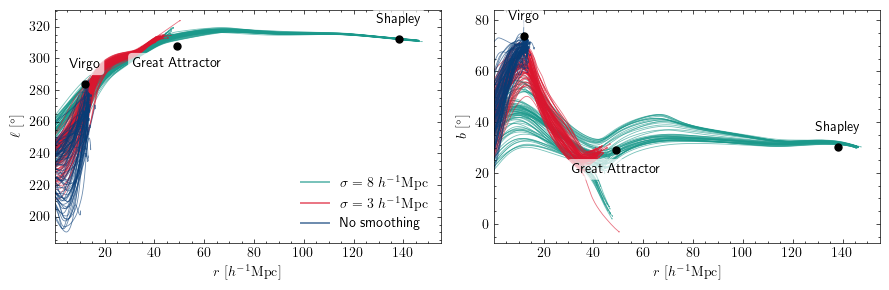

In [16]:
fname = "/Users/rstiskalek/Projects/FlowIntegrator/results/MW_streamlines.hdf5"
smoothing_scales = [0, 3, 8]
downsample = None


fig, axs = plot_mw_streamlines(fname, smoothing_scales, downsample=downsample)

fig.savefig("/Users/rstiskalek/Downloads/mw_streamlines_smoothing.pdf", dpi=300)

display(fig)

$\sigma=2.0\ h^{-1}\ \mathrm{Mpc}$: r = 41 -6.37/+2.01; ell = 313 -7.76/+1.36; b = 27.3 -4.13/+1.4
$\sigma=3.0\ h^{-1}\ \mathrm{Mpc}$: r = 41.3 -4.66/+2.01; ell = 313 -4.76/+1.07; b = 27.4 -4.33/+1.75
$\sigma=4.0\ h^{-1}\ \mathrm{Mpc}$: r = 41.8 -3.47/+1.46; ell = 312 -2.3/+1.25; b = 26.7 -4.56/+2.46


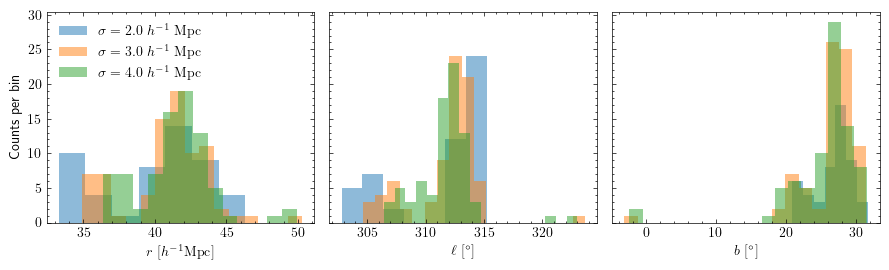

In [116]:
fnames = ["../results/ga_positions_sigma_2.0.txt",
          "../results/ga_positions_sigma_3.0.txt",
          "../results/ga_positions_sigma_4.0.txt",
          ]


# fnames = [f"../results/ga_positions_sigma_{i:.1f}.txt" for i in range(7, 10)]

fig, ax = plot_ga_positions(fnames, 681., r_min=22.5, kde=False)
# fig.savefig("/Users/rstiskalek/Downloads/ga_positions.pdf", dpi=300)
display(fig)

In [ ]:
pos = np.genfromtxt("../results/ga_positions_sigma_3.0.txt")[:, 1:]
center = np.full(3, 681/2)

# pos = flowi.cartesian_icrs_to_galactic_spherical(pos, center)
ga_position = np.array([310.20243187, 327.82457008, 317.06044731])

In [81]:
np.linalg.norm(pos - ga_position, axis=-1)

array([ 5.33395   ,  1.17794072,  3.79476388,  7.47126503,  1.29299525,
        6.70523629,  1.03763381,  2.83538326,  5.39262419,  2.08864863,
        5.69362693,  0.9723521 ,  1.75295011,  1.4442667 ,  1.48744852,
        6.35114544,  1.20871789,  2.50879019,  0.28884094,  4.49567296,
        7.45572499,  2.76345829,  4.3283879 ,  1.73030868,  2.06941702,
        7.59081568,  1.2345752 ,  3.59446047,  1.85123263,  2.4628046 ,
        6.66399576,  1.48902612,  2.2911277 ,  1.63758945,  4.14579574,
        5.79535311,  0.42067316,  3.21527921,  2.05522727,  2.20518778,
        6.07412833,  3.51826162,  3.7986019 ,  1.44147109,  4.25454883,
        6.43392513,  0.8323795 ,  1.14370824,  1.16151649,  3.6635164 ,
        7.44333933,  3.71383853,  2.80358928,  0.43192528,  3.7647016 ,
       26.70253493,  0.59261263,  1.16970946,  2.14707358,  3.36314344,
        7.45345189,  1.52999441,  2.16995169,  0.81260918,  0.65003808,
        7.11798087,  0.6206436 ,  0.89290431,  5.71307247,  1.81

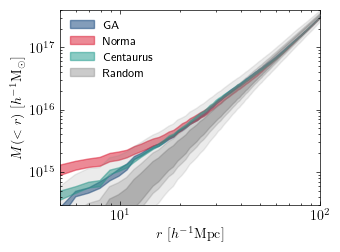

In [106]:
fnames = [
    "/Users/rstiskalek/Projects/FlowIntegrator/results/GA_enclosed_mass.hdf5",
    "/Users/rstiskalek/Projects/FlowIntegrator/results/Norma_enclosed_mass.hdf5",
    "/Users/rstiskalek/Projects/FlowIntegrator/results/Centaurus_enclosed_mass.hdf5",
    ]
labels = ["GA", "Norma", "Centaurus"]

fig, ax = plot_ga_enclosed_mass(fnames, labels=labels)
fig.savefig("/Users/rstiskalek/Downloads/ga_enclosed_mass.pdf", dpi=300, bbox_inches="tight")
display(fig)

In [123]:
fname = "/Users/rstiskalek/Projects/FlowIntegrator/results/GA_analysis.hdf5"

sigma, M = load_ga_metrics(fname, value="ga_mass")
sigma, V = load_ga_metrics(fname, value="ga_volume")

logM = np.log10(M)

R = (V * 3 / (4 * np.pi)) ** (1/3)

In [129]:
sigma

array([ 0.,  2.,  4., 16.])

M [4.0 Mpc/h] = 16.378 (+0.081/-0.037)
R [4.0 Mpc/h] = 42.140 (+3.08/-0.788)


/var/folders/kv/90qm_jx508j4zhvy56lhf09m0000gn/T/ipykernel_17324/2971711525.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


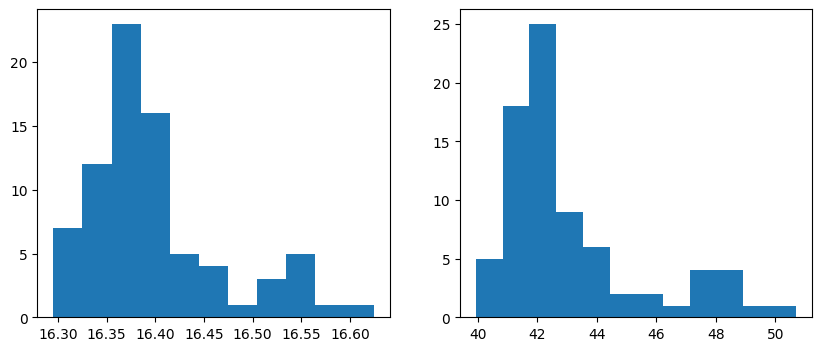

In [131]:
k = 2

print(f"M [{sigma[k]:.1f} Mpc/h] = {np.nanpercentile(logM[:, k], 50):.3f} (+{np.nanpercentile(logM[:, k], 84)-np.nanpercentile(logM[:, k], 50):.3f}/-{np.nanpercentile(logM[:, k], 50)-np.nanpercentile(logM[:, k], 16):.3f})")
print(f"R [{sigma[k]:.1f} Mpc/h] = {np.nanpercentile(R[:, k], 50):.3f} (+{np.nanpercentile(R[:, k], 84)-np.nanpercentile(R[:, k], 50):.3}/-{np.nanpercentile(R[:, k], 50)-np.nanpercentile(R[:, k], 16):.3f})")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(np.log10(M[:, k]), bins="auto")
ax[1].hist(R[:, k], bins="auto")

fig.show()


### Virgo position survival

In [138]:
grp = np.load("/Users/rstiskalek/Projects/FlowIntegrator/results/from_CB/halo_finder_snap001_l145_b66_d11.npz")
# grp = np.load("/Users/rstiskalek/Projects/FlowIntegrator/results/from_CB/halo_finder_snap001_l302_b32_d34.npz")


logM = np.log10(grp["masses"])
r = grp["distances"]
ell = grp["gal_l"]
b = grp["gal_b"]
def asym_err(x):
    p16, p50, p84 = np.nanpercentile(x, [16, 50, 84])
    return p50, p50 - p16, p84 - p50

for name, arr in [("logM", logM), ("r", r), ("ell", ell), ("b", b)]:
    mid, lo, hi = asym_err(arr)
    print(f"{name} = {mid:.3f} -{lo:.3f} +{hi:.3f}")

logM = 13.556 -0.268 +0.124
r = 11.754 -2.849 +1.772
ell = 147.284 -6.308 +8.921
b = 70.657 -9.173 +2.698


In [137]:
np.isfinite(r).sum() / len(r)

np.float64(0.6)

### Virgo movement

In [132]:
def gal_to_cart(r, ell, b):
    """Galactic (deg) + radial distance -> Cartesian xyz."""
    ell_rad = np.deg2rad(ell)
    b_rad = np.deg2rad(b)
    x = r * np.cos(b_rad) * np.cos(ell_rad)
    y = r * np.cos(b_rad) * np.sin(ell_rad)
    z = r * np.sin(b_rad)
    return np.vstack([x, y, z]).T

def cart_to_gal(xyz):
    """Cartesian xyz -> (r, ell_deg, b_deg)."""
    x, y, z = xyz[:,0], xyz[:,1], xyz[:,2]
    r = np.sqrt(x**2 + y**2 + z**2)
    ell = np.rad2deg(np.arctan2(y, x)) % 360
    b = np.rad2deg(np.arcsin(z / np.maximum(r, 1e-12)))
    return r, ell, b

def asym_err(x):
    p16, p50, p84 = np.percentile(x, [16, 50, 84])
    return p50, p50 - p16, p84 - p50

def compare_snapshots(file_new, file_ref):
    """Load two halo files, compute positional differences in Galactic coords,
    and print asymmetric percentile errors."""
    
    grp_new = np.load(file_new)
    grp_ref = np.load(file_ref)

    # Load quantities
    r1, ell1, b1 = grp_new["distances"], grp_new["gal_l"], grp_new["gal_b"]
    r0, ell0, b0 = grp_ref["distances"], grp_ref["gal_l"], grp_ref["gal_b"]

    # Convert both to Cartesian
    xyz1 = gal_to_cart(r1, ell1, b1)
    xyz0 = gal_to_cart(r0, ell0, b0)

    # Vector differences
    dxyz = xyz1 - xyz0

    # Convert difference vectors back to Galactic coords
    dr, dell, db = cart_to_gal(dxyz)

    # Report asymmetric errors
    for name, arr in [("d_r", dr), ("d_ell", dell), ("d_b", db)]:
        mid, lo, hi = asym_err(arr)
        print(f"{name} = {mid:.3f} -{lo:.3f} +{hi:.3f}")


# Example usage:
compare_snapshots(
    # "/Users/rstiskalek/Projects/FlowIntegrator/results/from_CB/halo_finder_snap004_l283_b74_d13.npz",
    # "/Users/rstiskalek/Projects/FlowIntegrator/results/from_CB/halo_finder_snap001_l283_b74_d13.npz",
    "/Users/rstiskalek/Projects/FlowIntegrator/results/from_CB/halo_finder_snap004_l302_b22_d34.npz",
    "/Users/rstiskalek/Projects/FlowIntegrator/results/from_CB/halo_finder_snap001_l302_b22_d34.npz"

)

d_r = 2.218 -0.500 +0.410
d_ell = 25.140 -13.960 +327.303
d_b = 42.743 -15.267 +11.371


In [99]:
r = 34.0
ell = 303.0
b = 21.7


ra, dec = flowi.galactic_to_radec(ell, b)

681 / 2 + gal_to_cart(r, ra, dec)

array([[315.55712222, 334.76738225, 318.1171954 ]])

In [129]:
from astropy.cosmology import FlatLambdaCDM

cosmo = FlatLambdaCDM(H0=68.1, Om0=0.306)


a = np.asarray([1, 2, 5, 10])
z = 1 / a - 1

print(a)
print(cosmo.age(z))

[ 1  2  5 10]
[13.76615402 24.7707825  40.41833332 52.35610439] Gyr
